# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [1]:
import numpy as np

# Insert your values
Name = "Yi Fang Too" # Replace with your name
CID = 2267627 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Yi Fang Too [CID: 2267627]

Your challenge code is E


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

In this code we try to solve a regression problem in order to predict the yield strength of steel, based on input compositions from a dataset of 312. The best-performing model in the benchmark was TPOT-Mat, which achieved a MAE of $79.9 \pm 13.6$ MPa.


## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [2]:
# Installation of libraries
!pip install matminer # Datasets and featurisation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 25.8 MB/s eta 0:00:00
   ━━━━━━

In [3]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
#info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_steels
Description: Matbench v0.1 test dataset for predicting steel yield strengths from chemical composition alone. Retrieved from Citrine informatics. Deduplicated. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	yield strength: Target variable. Experimentally measured steel yield strengths, in MPa.
Num Entries: 312
Reference: https://citrination.com/datasets/153092/
Bibtex citations: ["@Article{Dunn2020,\nauthor={Dunn, Alexander\nand Wang, Qi\nand Ganose, Alex\nand Dopp, Daniel\nand Jain, Anubhav},\ntitle={Benchmarking materials property prediction methods: the Matbench test set and Automatminer reference algorithm},\njournal={npj Computational Materials},\nyear={2020},\nmonth={Sep},\nday={15},\nvolume={6},\nnumber={1},\npages={138},\nabstract={We present a benchmark test suite and an automated mac

In [27]:
# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_steels")
raw_df = df.copy()
df.head(10)

,composition,yield strength
0,Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...,2411.5
1,Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....,1123.1
2,Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....,1736.3
3,Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...,2487.3
4,Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...,2249.6
5,Fe0.636C0.00881Mn0.000203Si0.00972Cr0.135Ni0.0...,1328.3
6,Fe0.644Mn0.000521Si0.00102Cr0.000110Ni0.177Mo0...,2501.1
7,Fe0.646C0.00479Mn0.00597Si0.00492Cr0.135Ni0.00...,1228.9
8,Fe0.648C0.000453Mn0.0000991Si0.0386Cr0.183Ni0....,1088.6
9,Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....,1502.0


In [28]:
df.describe() # view summary statistics

,yield strength
count,312.000000
mean,1420.998397
std,301.894169
min,1005.900000
25%,1219.475000
50%,1344.200000
75%,1576.075000
max,2510.300000


In [13]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df.copy(), title='Pandas Profiling Report of Cp dataset', html={'style':{'full_width':True}})
profile.to_widgets()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
matminer 0.10.1 requires scipy>=1.17.0

/usr/local/lib/python3.12/dist-packages/ydata_profiling/profile_report.py:535: UserWarning: Ipywidgets is not yet fully supported on Google Colab (https://github.com/googlecolab/colabtools/issues/60).As an alternative, you can use the HTML report. See the documentation for more information.
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 62.21it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render widgets:   0%|          | 0/1 [00:00<?, ?it/s]

ValueError: ('widget type not understood', 'overview_tabs')

Since the column names are fairly descriptive and not too long, we'll leave them alone. We will now clean the data by removing duplicates, NaN values, and unphysical values such as negative yield strength. To better visualise the data above and the overall  distribution, we can also use box plots and histograms.

In [17]:
print(f'DataFrame shape before cleanup: {raw_df.shape}')

df = df.dropna(axis=0, how='any')
print(f'DataFrame shape after dropping NaNs: {df.shape}')

df = df.drop_duplicates()
print(f'DataFrame shape after dropping duplicates: {df.shape}')

DataFrame shape before cleanup: (312, 2)
DataFrame shape after dropping NaNs: (312, 2)
DataFrame shape after dropping duplicates: (312, 2)


In [22]:
# packages for data visualisation
import matplotlib.pyplot as plt
import pprint
import seaborn as sns

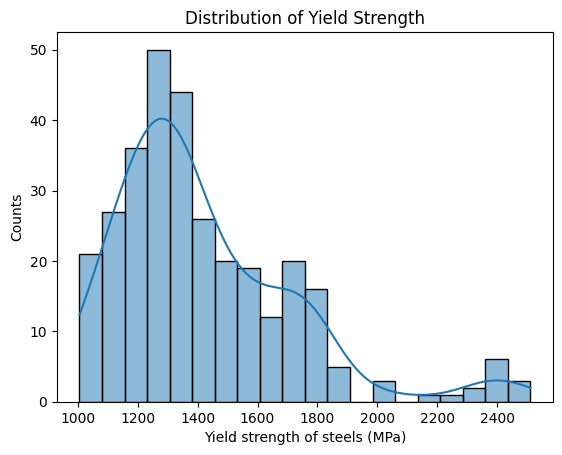

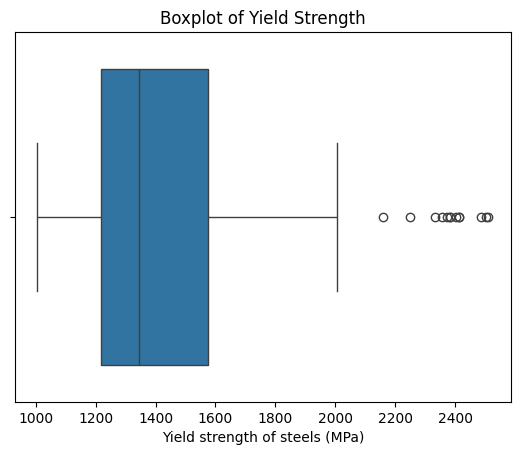

In [25]:
y = df['yield strength'].values

# visualising yield strength distribution

sns.histplot(y, bins=20, kde=True)
plt.title("Distribution of Yield Strength")
plt.ylabel("Counts")
plt.xlabel("Yield strength of steels (MPa)")
plt.show()

sns.boxplot(x=y)
plt.title("Boxplot of Yield Strength")
plt.xlabel("Yield strength of steels (MPa)")
plt.show()

So our dataset is perfectly fine. Well, better safe than sorry. It's a good thing anyway since it's kinda small. We can see from the minimum value given above that there are no negative values so we can skip that step.

Besides tidying up the values, we need to ensure the composition is actually useful i.e. not a string.

In [32]:

from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition(target_col_id='formula')
df2 = str_to_comp.featurize_dataframe(df, col_id='composition')

df2 = df2.dropna(axis=0, how='any')
print(f'DataFrame shape after dropping NaNs: {df2.shape}')

df2.head(10)


# distribution of compositions in dataset
# data: composition
# number of different compositions
# min, max, mean of elements
# t-SNE, UMAP, elemental prevalence mapping


StrToComposition:   0%|          | 0/312 [00:00<?, ?it/s]

DataFrame shape after dropping NaNs: (312, 3)


,composition,yield strength,formula
0,Fe0.620C0.000953Mn0.000521Si0.00102Cr0.000110N...,2411.5,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
1,Fe0.623C0.00854Mn0.000104Si0.000203Cr0.147Ni0....,1123.1,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, W, Al)"
2,Fe0.625Mn0.000102Si0.000200Cr0.0936Ni0.129Mo0....,1736.3,"(Fe, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
3,Fe0.634C0.000478Mn0.000523Si0.00102Cr0.000111N...,2487.3,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
4,Fe0.636C0.000474Mn0.000518Si0.00101Cr0.000109N...,2249.6,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
5,Fe0.636C0.00881Mn0.000203Si0.00972Cr0.135Ni0.0...,1328.3,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al)"
6,Fe0.644Mn0.000521Si0.00102Cr0.000110Ni0.177Mo0...,2501.1,"(Fe, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
7,Fe0.646C0.00479Mn0.00597Si0.00492Cr0.135Ni0.00...,1228.9,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, Al)"
8,Fe0.648C0.000453Mn0.0000991Si0.0386Cr0.183Ni0....,1088.6,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, Nb, Co, Al, Ti)"
9,Fe0.648C0.00751Mn0.000103Si0.000201Cr0.158Ni0....,1502.0,"(Fe, C, Mn, Si, Cr, Ni, Mo, V, N, Nb, Co, Al)"


Now that we have our elements, we can visualise some useful features e.g. element prevalence and stuff like that. also t-SNE, UMAP. leaving that for later though because it's not inside the tutorial notebook lol.

Time for some splits!

In [44]:
from sklearn.model_selection import train_test_split


In [45]:
y = df2['yield strength']
X = df2['formula']

# unique?
unique_formulae = X.unique()
print(f'{len(unique_formulae)} unique formulae') # do i still need this with drop_duplicates?

312 unique formulae


Now that we have our splits we can do some featurization.

In [52]:
np.random.seed(SEED)
from matminer.featurizers.composition import Stoichiometry
from matminer.featurizers.composition import ElementFraction
from matminer.featurizers.composition import ValenceOrbital
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

featurizer = ElementProperty.from_preset("magpie")

# Convert the 'composition' column from strings to pymatgen.core.Composition objects in the DataFrame
df["composition"] = df["composition"].apply(Composition)

# Now, featurize the DataFrame using the updated 'composition' column.
# The featurizer will now correctly find Composition objects in the specified column.
X_feat = featurizer.featurize_dataframe(df, "composition")


ElementProperty:   0%|          | 0/312 [00:00<?, ?it/s]

In [55]:

# Create a working copy of X_feat with only numerical features
X_cleaned_features = X_feat.drop(columns=["composition", "yield strength"])

# Drop any columns that contain NaN values (might occur from featurization)
X_cleaned_features = X_cleaned_features.dropna(axis=1)

print(len(X_cleaned_features))


312


In [66]:
train_size = 0.65
val_size = 0.20
test_size = 1 - train_size - val_size
SEED = 42

X_train_unscaled, X_test_unscaled, y_train, y_test = train_test_split(X_cleaned_features, y, test_size=test_size, random_state=SEED)
X_train_unscaled, X_val_unscaled, y_train, y_val = train_test_split(X_train_unscaled, y_train, test_size=val_size/(1-test_size), random_state=SEED)
print(f'Sizes: {len(X_train_unscaled)}, {len(X_val_unscaled)}, {len(X_test_unscaled)}')


Sizes: 202, 63, 47


In [68]:
print(X_train_unscaled.shape)
X_train_unscaled.head()

(202, 132)


,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
232,13.0,42.0,29.0,26.057407,0.761766,26.0,43.0,78.0,35.0,54.970458,...,2.110663,1.682183,0.659448,2.110663,194.0,229.0,35.0,228.502594,0.887984,229.0
158,6.0,42.0,36.0,26.147384,0.699151,26.0,43.0,78.0,35.0,55.866167,...,2.110663,1.723340,0.560897,2.110663,194.0,229.0,35.0,225.948091,4.697050,229.0
187,6.0,42.0,36.0,25.771867,1.112628,26.0,43.0,78.0,35.0,55.045453,...,2.110663,1.632335,0.718652,2.110663,194.0,229.0,35.0,228.525313,0.851895,229.0
97,6.0,74.0,68.0,26.037977,0.881481,26.0,43.0,78.0,35.0,55.311305,...,2.110663,1.715842,0.547619,2.110663,194.0,229.0,35.0,223.341125,9.187385,229.0
195,6.0,42.0,36.0,25.781923,1.097126,26.0,43.0,78.0,35.0,55.035226,...,2.110663,1.633541,0.717292,2.110663,194.0,229.0,35.0,228.526841,0.849504,229.0


In [62]:
# scaling
from sklearn.preprocessing import StandardScaler # alt: robus and minmax
from sklearn.preprocessing import normalize


In [69]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_unscaled)
X_val = scaler.transform(X_val_unscaled)
X_test = scaler.transform(X_test_unscaled)

X_train = normalize(X_train)
X_val = normalize(X_val)
X_test = normalize(X_test)

In [54]:
corr = X.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

TypeError: Series.corr() missing 1 required positional argument: 'other'

Now we look at model choices (import these) and define some helper functions. also build dataframe to store results. also define models by instantiating dictionary and storing the models and whatever. talk a bit about the model choices.

In [ ]:
# Test-train split
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Use the pre-processed features from X_cleaned_features for selection
X_for_selection = X_cleaned_features.copy()
y_for_selection = X_feat["yield strength"] # y remains the original target from X_feat

selector = SelectFromModel(RandomForestRegressor(random_state=42))
selector.fit(X_for_selection, y_for_selection)

# Get the names of the selected features
selected_feature_names = X_for_selection.columns[selector.get_support()]

# Redefine the global X and y using only the selected features
X = X_for_selection[selected_feature_names]
y = y_for_selection

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

In [ ]:
# Random forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("Random Forest MAE:", mae)

MAE: 93.902246031746


In [ ]:
!pip install xgboost

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)

MAE: 94.67286086309524


In [ ]:
from sklearn.kernel_ridge import KernelRidge

kernel = KernelRidge(kernel="rbf")
kernel.fit(X_train, y_train)

preds = kernel.predict(X_test)

mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)


MAE: 321.17625967512026


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_absolute_error"
)

search.fit(X_train, y_train)

print(search.best_params_)

{'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBRegressor(),
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    "max_depth": [3,4,5,6,8],
    "learning_rate": [0.01,0.05,0.1],
    "n_estimators": [200,400,600],
    "subsample": [0.7,0.8,1.0],
}

search = RandomizedSearchCV(
    XGBRegressor(),
    params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)

{'subsample': 1.0, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.05}


In [ ]:
best_model = search.best_estimator_

preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

In [ ]:
final_pred = (pred_rf + pred_xgb + pred_krr) / 3

## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

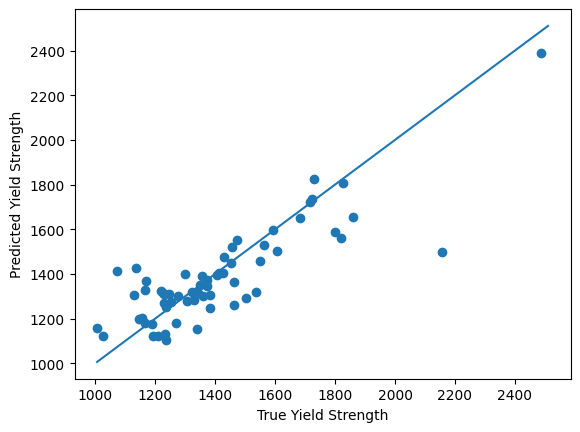

In [ ]:
plt.scatter(y_test, preds)

plt.xlabel("True Yield Strength")
plt.ylabel("Predicted Yield Strength")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5,
                         scoring="neg_mean_absolute_error")

print("CV MAE:", -scores.mean())

CV MAE: 189.61356948844724


In [ ]:
from sklearn.model_selection import RepeatedKFold



In [ ]:
from sklearn.metrics import mean_absolute_error

preds = search.best_estimator_.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("Final MAE:", mae)

Final MAE: 95.26400320870536


Text(0.5, 1.0, 'Feature Importance')

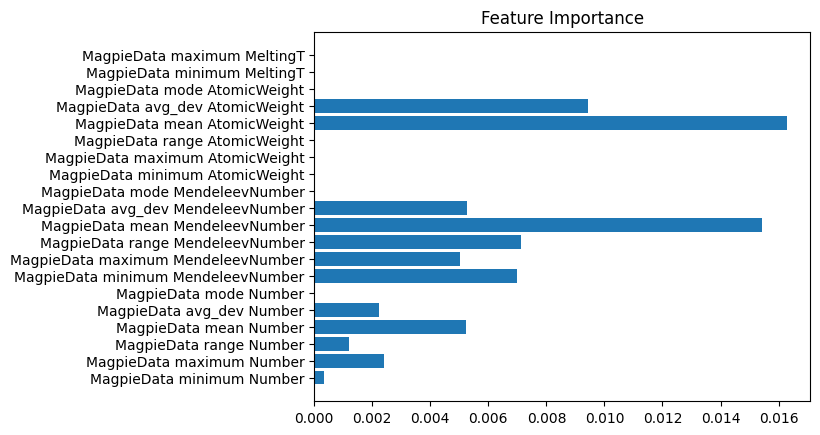

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X.columns[:20], importance[:20])
plt.title("Feature Importance")

Text(0.5, 1.0, 'Feature Importance')

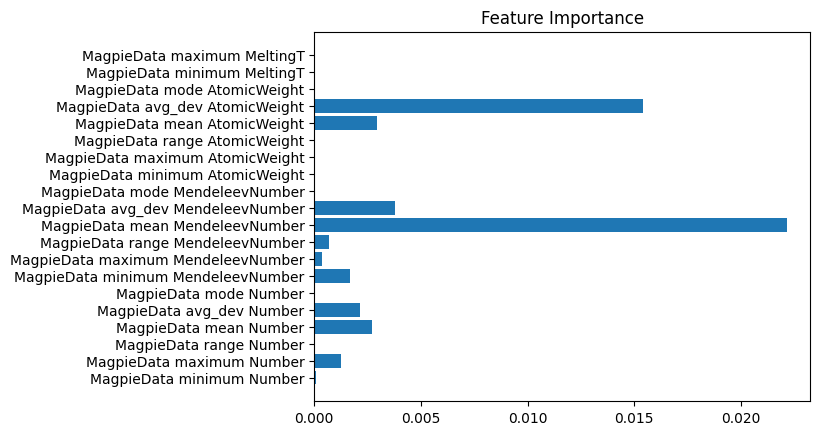

In [ ]:
importances = best_model.feature_importances_
plt.barh(X.columns[:20], importances[:20])
plt.title("Feature Importance")

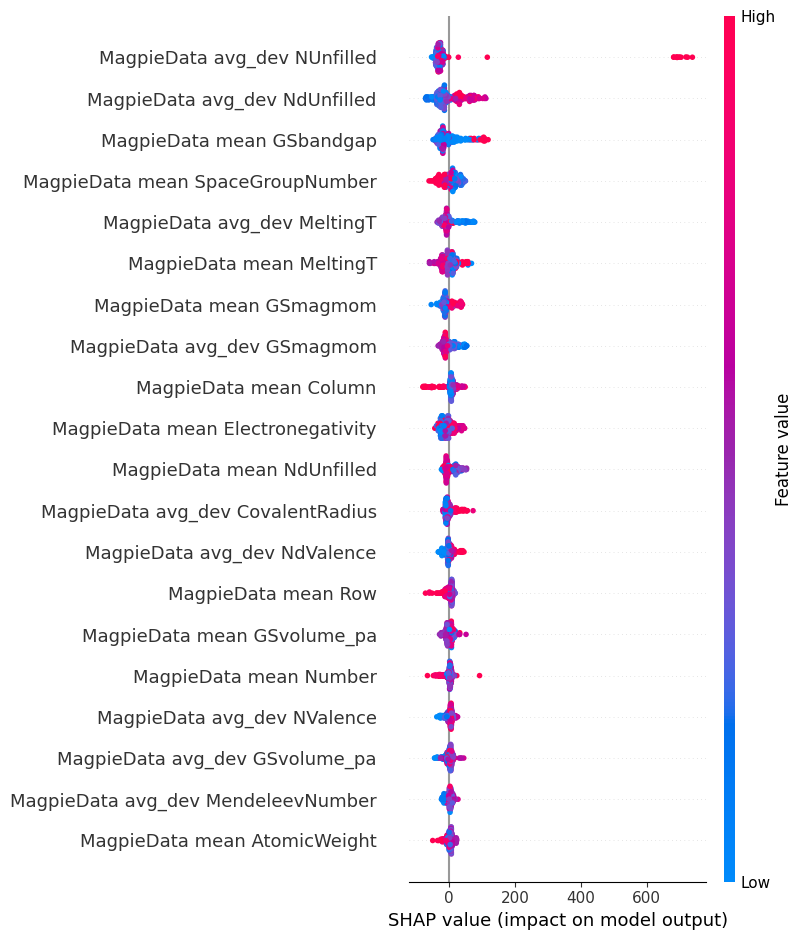

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from xgboost import XGBRegressor

base_models = [
    ("rf", RandomForestRegressor(n_estimators=300)),
    ("xgb", XGBRegressor(n_estimators=500, learning_rate=0.05)),
    ("krr", KernelRidge(kernel="rbf"))
]

stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

stack_model.fit(X_train, y_train)
preds = stack_model.predict(X_test)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge

model = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf"))
])

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

In [ ]:
# Spare cell




## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).